In [1]:
!pip install rdkit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 36.6/36.6 MB 49.0 MB/s eta 0:00:00


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from rdkit import Chem
from rdkit.Chem import Descriptors, Draw, AllChem
from rdkit.Chem.Draw import IPythonConsole
from rdkit.Chem import PandasTools
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (classification_report, confusion_matrix, 
                           roc_auc_score, accuracy_score, roc_curve, auc)
from sklearn.feature_selection import SelectKBest, f_classif
import warnings

warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
pd.set_option('display.max_columns', None)

In [3]:
df = pd.read_csv('/kaggle/input/tox21-dataset/tox21.csv')
print(f"dataset loaded with {df.shape[0]} rows and {df.shape[1]} columns")

dataset loaded with 7831 rows and 14 columns


In [4]:
print("="*80)
print("TOX21 DATASET OVERVIEW")
print("="*80)

print("\n📊 First 5 rows:")
display(df.head())

print("\n🔍 Dataset information:")
print(df.info())

print("\n📈 Descriptive statistics of targets:")
# Identify target columns
target_columns = ['NR-AR', 'NR-AR-LBD', 'NR-AhR', 'NR-Aromatase', 'NR-ER', 
                  'NR-ER-LBD', 'NR-PPAR-gamma', 'SR-ARE', 'SR-ATAD5', 
                  'SR-HSE', 'SR-MMP', 'SR-p53']

# Convert targets to numeric
for col in target_columns:
    df[col] = pd.to_numeric(df[col], errors='coerce')

display(df[target_columns].describe())

TOX21 DATASET OVERVIEW

📊 First 5 rows:


,NR-AR,NR-AR-LBD,NR-AhR,NR-Aromatase,NR-ER,NR-ER-LBD,NR-PPAR-gamma,SR-ARE,SR-ATAD5,SR-HSE,SR-MMP,SR-p53,mol_id,smiles
0,0.0,0.0,1.0,NaN,NaN,0.0,0.0,1.0,0.0,0.0,0.0,0.0,TOX3021,CCOc1ccc2nc(S(N)(=O)=O)sc2c1
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,0.0,NaN,0.0,0.0,TOX3020,CCN1C(=O)NC(c2ccccc2)C1=O
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,0.0,NaN,NaN,TOX3024,CC[C@]1(O)CC[C@H]2[C@@H]3CCC4=CCCC[C@@H]4[C@H]...
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,0.0,NaN,0.0,0.0,TOX3027,CCCN(CC)C(CC)C(=O)Nc1c(C)cccc1C
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,TOX20800,CC(O)(P(=O)(O)O)P(=O)(O)O



🔍 Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7831 entries, 0 to 7830
Data columns (total 14 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   NR-AR          7265 non-null   float64
 1   NR-AR-LBD      6758 non-null   float64
 2   NR-AhR         6549 non-null   float64
 3   NR-Aromatase   5821 non-null   float64
 4   NR-ER          6193 non-null   float64
 5   NR-ER-LBD      6955 non-null   float64
 6   NR-PPAR-gamma  6450 non-null   float64
 7   SR-ARE         5832 non-null   float64
 8   SR-ATAD5       7072 non-null   float64
 9   SR-HSE         6467 non-null   float64
 10  SR-MMP         5810 non-null   float64
 11  SR-p53         6774 non-null   float64
 12  mol_id         7831 non-null   object 
 13  smiles         7831 non-null   object 
dtypes: float64(12), object(2)
memory usage: 856.6+ KB
None

📈 Descriptive statistics of targets:


,NR-AR,NR-AR-LBD,NR-AhR,NR-Aromatase,NR-ER,NR-ER-LBD,NR-PPAR-gamma,SR-ARE,SR-ATAD5,SR-HSE,SR-MMP,SR-p53
count,7265.000000,6758.000000,6549.000000,5821.000000,6193.000000,6955.000000,6450.000000,5832.000000,7072.000000,6467.000000,5810.000000,6774.000000
mean,0.042533,0.035070,0.117270,0.051538,0.128048,0.050324,0.028837,0.161523,0.037330,0.057523,0.158003,0.062445
std,0.201815,0.183969,0.321766,0.221110,0.334170,0.218627,0.167362,0.368044,0.189583,0.232857,0.364776,0.241979
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


1. EXPLORATORY DATA ANALYSIS (EDA)

🎯 1.1 TOXICOLOGICAL TARGET DISTRIBUTIONS


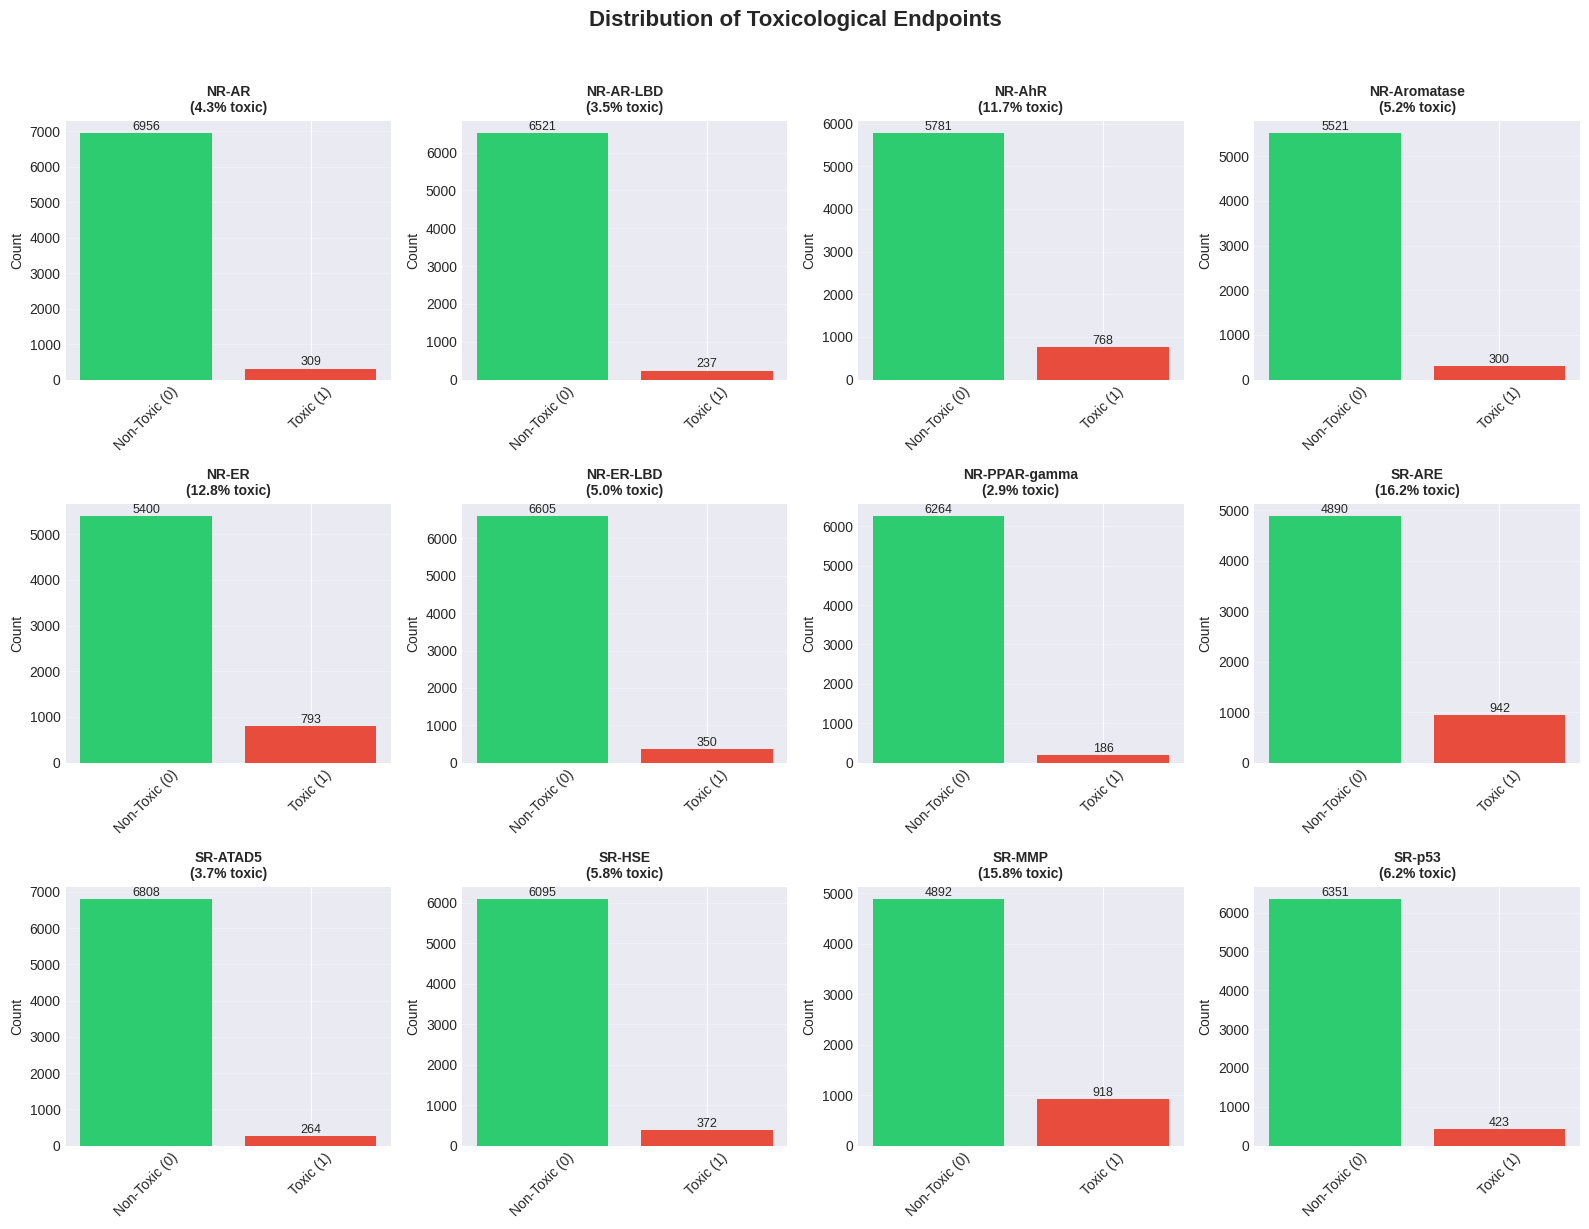

In [5]:
print("="*80)
print("1. EXPLORATORY DATA ANALYSIS (EDA)")
print("="*80)

# 1.1 Target distributions
print("\n🎯 1.1 TOXICOLOGICAL TARGET DISTRIBUTIONS")

fig, axes = plt.subplots(3, 4, figsize=(16, 12))
axes = axes.flatten()

for idx, target in enumerate(target_columns):
    ax = axes[idx]
    target_data = df[target].dropna()
    
    if len(target_data) > 0:
        # Count values
        counts = target_data.value_counts().sort_index()
        
        # Create plot
        bars = ax.bar(['Non-Toxic (0)', 'Toxic (1)'], 
                     [counts.get(0, 0), counts.get(1, 0)],
                     color=['#2ecc71', '#e74c3c'])
        
        # Add numbers
        for bar in bars:
            height = bar.get_height()
            ax.text(bar.get_x() + bar.get_width()/2., height + 5,
                   f'{int(height)}', ha='center', va='bottom', fontsize=9)
        
        # Calculate percentage
        total = len(target_data)
        pos_rate = counts.get(1, 0) / total * 100
        
        ax.set_title(f'{target}\n({pos_rate:.1f}% toxic)', fontsize=10, fontweight='bold')
        ax.set_ylabel('Count')
        ax.tick_params(axis='x', rotation=45)
        
        # Add grid
        ax.grid(True, alpha=0.3, axis='y')
        
        # Remove spines
        for spine in ['top', 'right']:
            ax.spines[spine].set_visible(False)
    else:
        ax.text(0.5, 0.5, 'No data', ha='center', va='center')
        ax.set_title(target, fontsize=10)

plt.suptitle('Distribution of Toxicological Endpoints', fontsize=16, y=1.02, fontweight='bold')
plt.tight_layout()
plt.show()


⚠️ 1.2 MISSING VALUES ANALYSIS

Total cells with missing values: 16,026
Total missing percentage: 14.62%

Top 20 columns with most missing values:


,Column,Missing Values,Percentage (%)
10,SR-MMP,2021,25.807687
3,NR-Aromatase,2010,25.667220
7,SR-ARE,1999,25.526753
4,NR-ER,1638,20.916869
6,NR-PPAR-gamma,1381,17.635040
9,SR-HSE,1364,17.417954
2,NR-AhR,1282,16.370834
1,NR-AR-LBD,1073,13.701954
11,SR-p53,1057,13.497638
5,NR-ER-LBD,876,11.186311


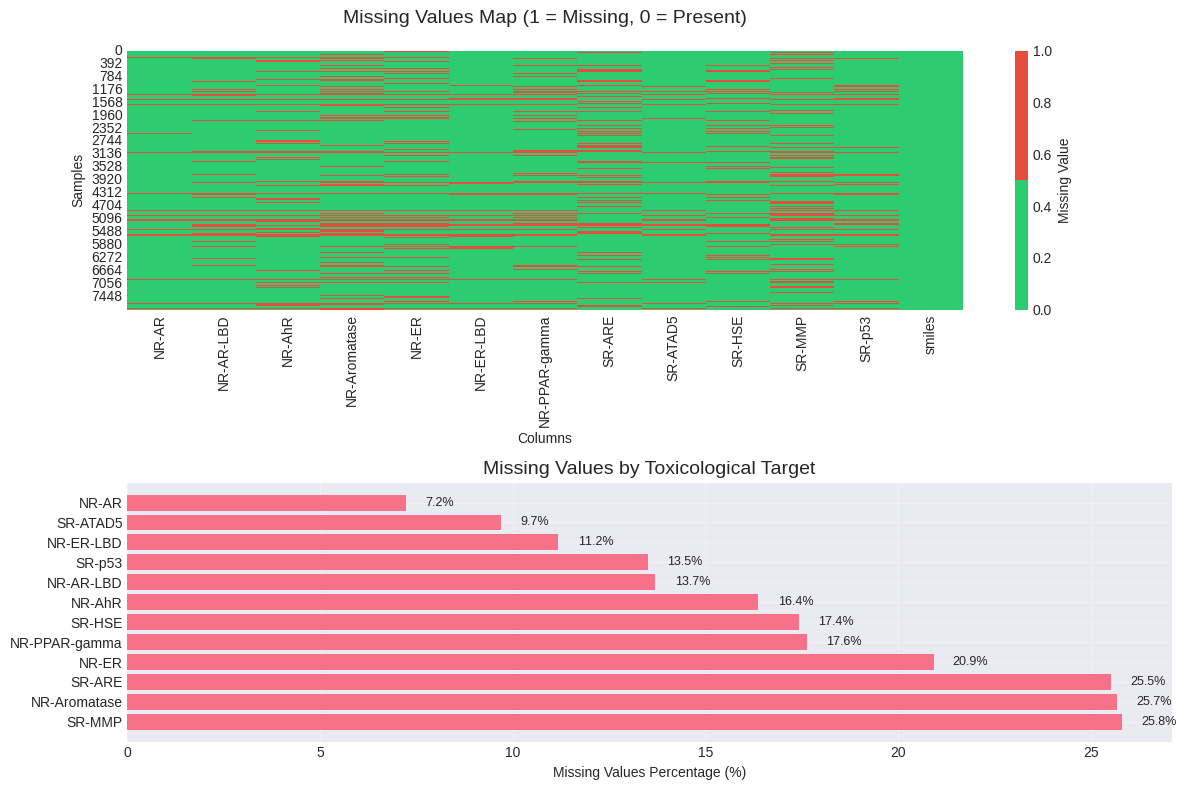

In [6]:
# 1.2 Missing values analysis
print("\n⚠️ 1.2 MISSING VALUES ANALYSIS")

# Calculate missing values per column
missing_data = pd.DataFrame({
    'Column': df.columns,
    'Missing Values': df.isnull().sum().values,
    'Percentage (%)': (df.isnull().sum() / len(df) * 100).values
})

print(f"\nTotal cells with missing values: {df.isnull().sum().sum():,}")
print(f"Total missing percentage: {(df.isnull().sum().sum() / (df.shape[0] * df.shape[1]) * 100):.2f}%")

# Top 20 columns with most missing values
missing_data_sorted = missing_data.sort_values('Percentage (%)', ascending=False)
print("\nTop 20 columns with most missing values:")
display(missing_data_sorted.head(20))

# Missing values visualization
plt.figure(figsize=(12, 8))
plt.subplot(2, 1, 1)

# Missing values heatmap (only first 50 columns for visualization)
cols_to_show = target_columns + ['smiles']  # Show only targets and smiles
missing_matrix = df[cols_to_show].isnull()

sns.heatmap(missing_matrix, cbar_kws={'label': 'Missing Value'}, 
            cmap=['#2ecc71', '#e74c3c'])
plt.title('Missing Values Map (1 = Missing, 0 = Present)', fontsize=14, pad=20)
plt.xlabel('Columns')
plt.ylabel('Samples')

plt.subplot(2, 1, 2)
# Missing percentage per target
target_missing = missing_data_sorted[missing_data_sorted['Column'].isin(target_columns)]
bars = plt.barh(target_missing['Column'], target_missing['Percentage (%)'])
plt.xlabel('Missing Values Percentage (%)')
plt.title('Missing Values by Toxicological Target', fontsize=14)
plt.grid(True, alpha=0.3)

# Add values on bars
for bar in bars:
    width = bar.get_width()
    plt.text(width + 0.5, bar.get_y() + bar.get_height()/2,
            f'{width:.1f}%', va='center', fontsize=9)

plt.tight_layout()
plt.show()


🔗 1.3 CORRELATION MATRIX BETWEEN TARGETS


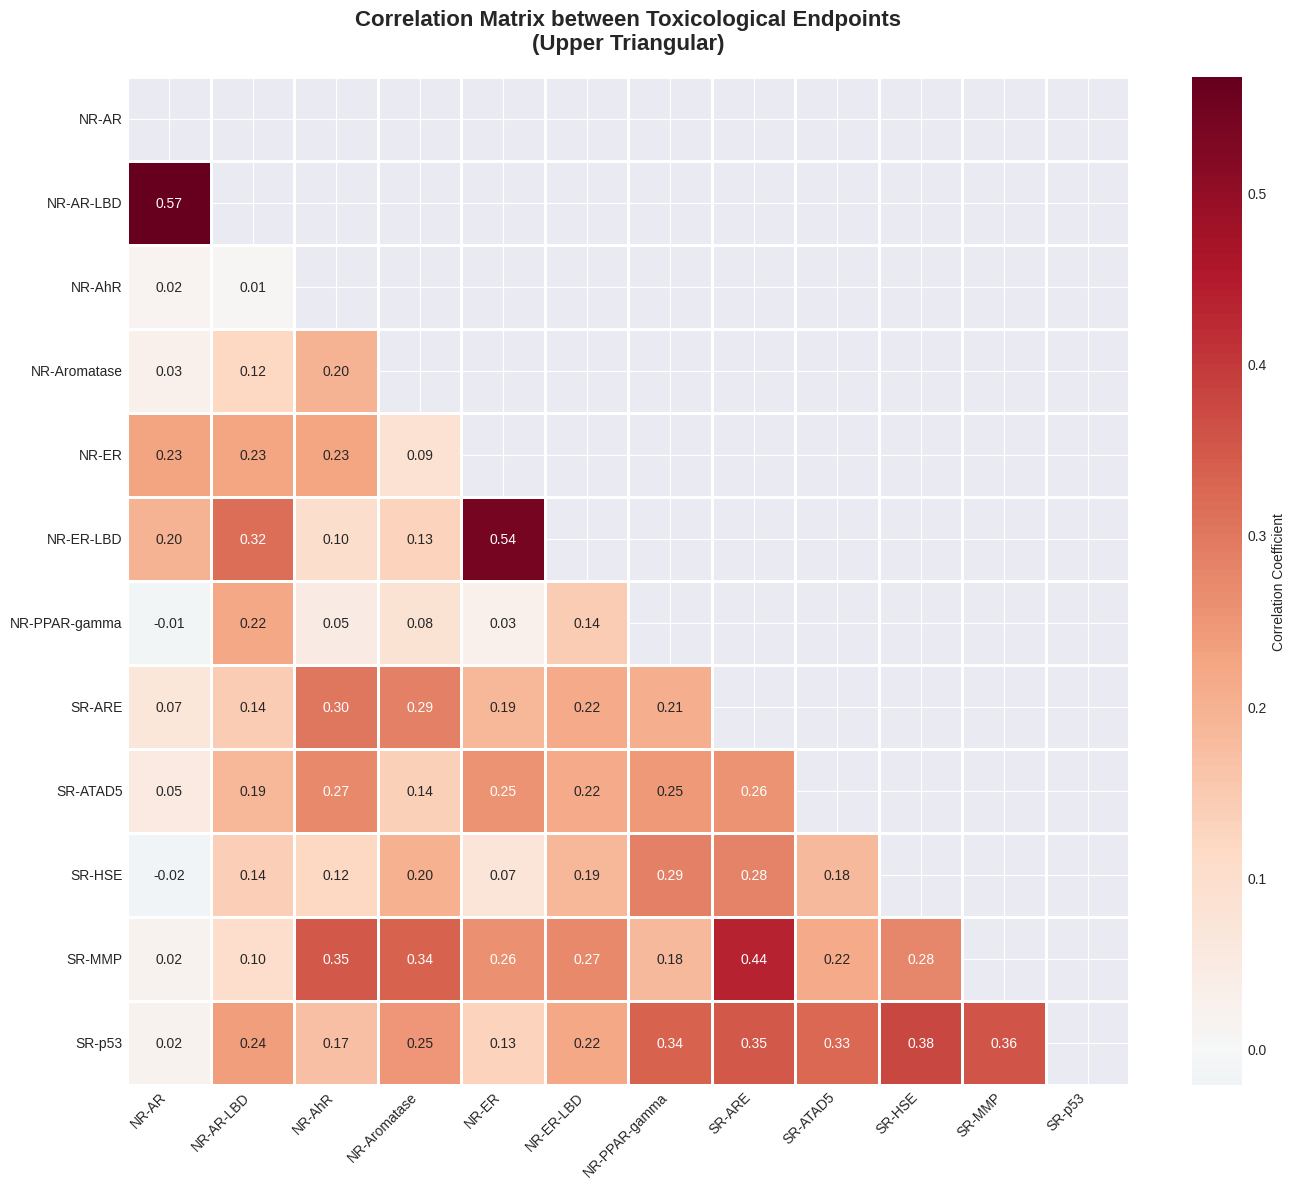


🔍 Strong correlations (|r| > 0.5):


,Target 1,Target 2,Correlation
0,NR-AR,NR-AR-LBD,0.567408
1,NR-ER,NR-ER-LBD,0.541272


In [7]:
# 1.3 Correlation matrix between targets
print("\n🔗 1.3 CORRELATION MATRIX BETWEEN TARGETS")

# Calculate correlation
correlation_matrix = df[target_columns].corr()

plt.figure(figsize=(14, 12))
mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))
sns.heatmap(correlation_matrix, mask=mask, annot=True, cmap='RdBu_r',
           center=0, fmt='.2f', linewidths=1, linecolor='white',
           cbar_kws={'label': 'Correlation Coefficient'})

plt.title('Correlation Matrix between Toxicological Endpoints\n(Upper Triangular)', 
          fontsize=16, pad=20, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# Identify strong correlations
print("\n🔍 Strong correlations (|r| > 0.5):")
strong_correlations = []
for i in range(len(correlation_matrix.columns)):
    for j in range(i+1, len(correlation_matrix.columns)):
        corr = correlation_matrix.iloc[i, j]
        if abs(corr) > 0.5 and not np.isnan(corr):
            strong_correlations.append({
                'Target 1': correlation_matrix.columns[i],
                'Target 2': correlation_matrix.columns[j],
                'Correlation': corr
            })

if strong_correlations:
    strong_corr_df = pd.DataFrame(strong_correlations)
    display(strong_corr_df.sort_values('Correlation', ascending=False))
else:
    print("No strong correlations found (|r| > 0.5)")

2. CHEMICAL DATA ANALYSIS WITH RDKIT

🧪 2.1 MOLECULAR PROPERTIES EXTRACTION
Converting SMILES to RDKit Molecule objects...
Converted 1000 molecules from 1000 samples

🔬 Example molecular structures:


[00:44:44] WARNING: not removing hydrogen atom without neighbors


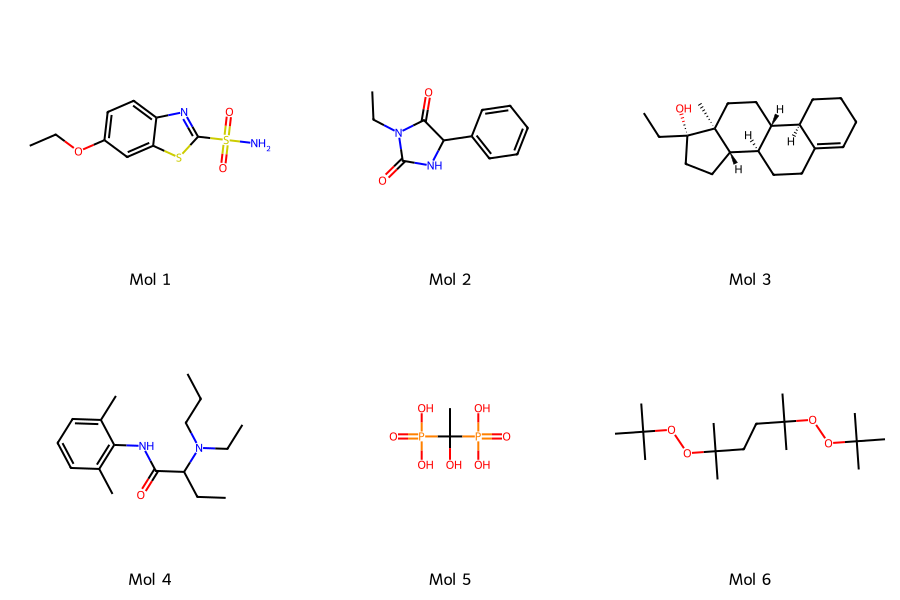

In [8]:
# 2. CHEMICAL DATA ANALYSIS WITH RDKIT
print("="*80)
print("2. CHEMICAL DATA ANALYSIS WITH RDKIT")
print("="*80)

print("\n🧪 2.1 MOLECULAR PROPERTIES EXTRACTION")
# Add RDKit Molecule column
print("Converting SMILES to RDKit Molecule objects...")

def safe_smiles_to_mol(smiles):
    """Convert SMILES to RDKit molecule with error handling"""
    if pd.isna(smiles):
        return None
    try:
        mol = Chem.MolFromSmiles(str(smiles))
        if mol is None:
            # Try without sanitization
            mol = Chem.MolFromSmiles(str(smiles), sanitize=False)
        return mol
    except:
        return None

# Convert first 1000 molecules for demonstration (for performance)
sample_size = min(1000, len(df))
df_sample = df.iloc[:sample_size].copy()
df_sample['Molecule'] = df_sample['smiles'].apply(safe_smiles_to_mol)

print(f"Converted {df_sample['Molecule'].notna().sum()} molecules from {sample_size} samples")

# Display some molecules
print("\n🔬 Example molecular structures:")
valid_mols = df_sample[df_sample['Molecule'].notna()].head(6)['Molecule'].tolist()
img = Draw.MolsToGridImage(valid_mols, molsPerRow=3, subImgSize=(300, 300),
                          legends=[f"Mol {i+1}" for i in range(len(valid_mols))])
display(img)

In [9]:
# 2.2 Calculate molecular descriptors
print("\n📊 2.2 MOLECULAR DESCRIPTORS CALCULATION")

def calculate_molecular_descriptors(mol):
    """Calculate basic molecular descriptors"""
    if mol is None:
        return None
    
    try:
        descriptors = {
            'MolWeight': Descriptors.MolWt(mol),
            'LogP': Descriptors.MolLogP(mol),
            'TPSA': Descriptors.TPSA(mol),
            'NumHDonors': Descriptors.NumHDonors(mol),
            'NumHAcceptors': Descriptors.NumHAcceptors(mol),
            'NumRotatableBonds': Descriptors.NumRotatableBonds(mol),
            'NumAtoms': mol.GetNumAtoms(),
            'NumHeavyAtoms': mol.GetNumHeavyAtoms(),
            'NumRings': Descriptors.RingCount(mol),
            'FractionCSP3': Descriptors.FractionCSP3(mol)
        }
        return descriptors
    except:
        return None

# Calculate descriptors for the sample
print("Calculating molecular descriptors...")
descriptors_list = []
for mol in df_sample['Molecule']:
    if mol is not None:
        desc = calculate_molecular_descriptors(mol)
        descriptors_list.append(desc)
    else:
        descriptors_list.append(None)

# Add to dataframe
desc_df = pd.DataFrame(descriptors_list, index=df_sample.index)
df_descriptors = pd.concat([df_sample, desc_df], axis=1)

print(f"\nDescriptors calculated for {desc_df.notna().all(axis=1).sum()} molecules")

# Descriptor statistics
print("\n📈 Molecular Descriptors Statistics:")
display(desc_df.describe())


📊 2.2 MOLECULAR DESCRIPTORS CALCULATION
Calculating molecular descriptors...

Descriptors calculated for 1000 molecules

📈 Molecular Descriptors Statistics:


,MolWeight,LogP,TPSA,NumHDonors,NumHAcceptors,NumRotatableBonds,NumAtoms,NumHeavyAtoms,NumRings,FractionCSP3
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000,1000.000000,1000.000000
mean,270.353183,2.221220,60.548200,1.286000,3.632000,4.251000,18.199000,18.19800,1.734000,0.462346
std,170.769724,2.539147,64.928096,2.183798,3.625703,4.342448,11.907022,11.90809,1.973611,0.331800
min,32.046000,-17.406400,0.000000,0.000000,0.000000,0.000000,1.000000,1.00000,0.000000,0.000000
25%,162.221000,1.036175,26.300000,0.000000,2.000000,1.000000,11.000000,11.00000,1.000000,0.166667
50%,237.963500,2.244200,46.335000,1.000000,3.000000,3.000000,16.000000,16.00000,1.000000,0.421053
75%,324.507250,3.579625,76.562500,2.000000,4.000000,6.000000,22.000000,22.00000,3.000000,0.750000
max,1701.206000,22.611800,777.980000,28.000000,46.000000,40.000000,122.000000,122.00000,30.000000,1.000000



📊 2.3 MOLECULAR DESCRIPTORS VISUALIZATION


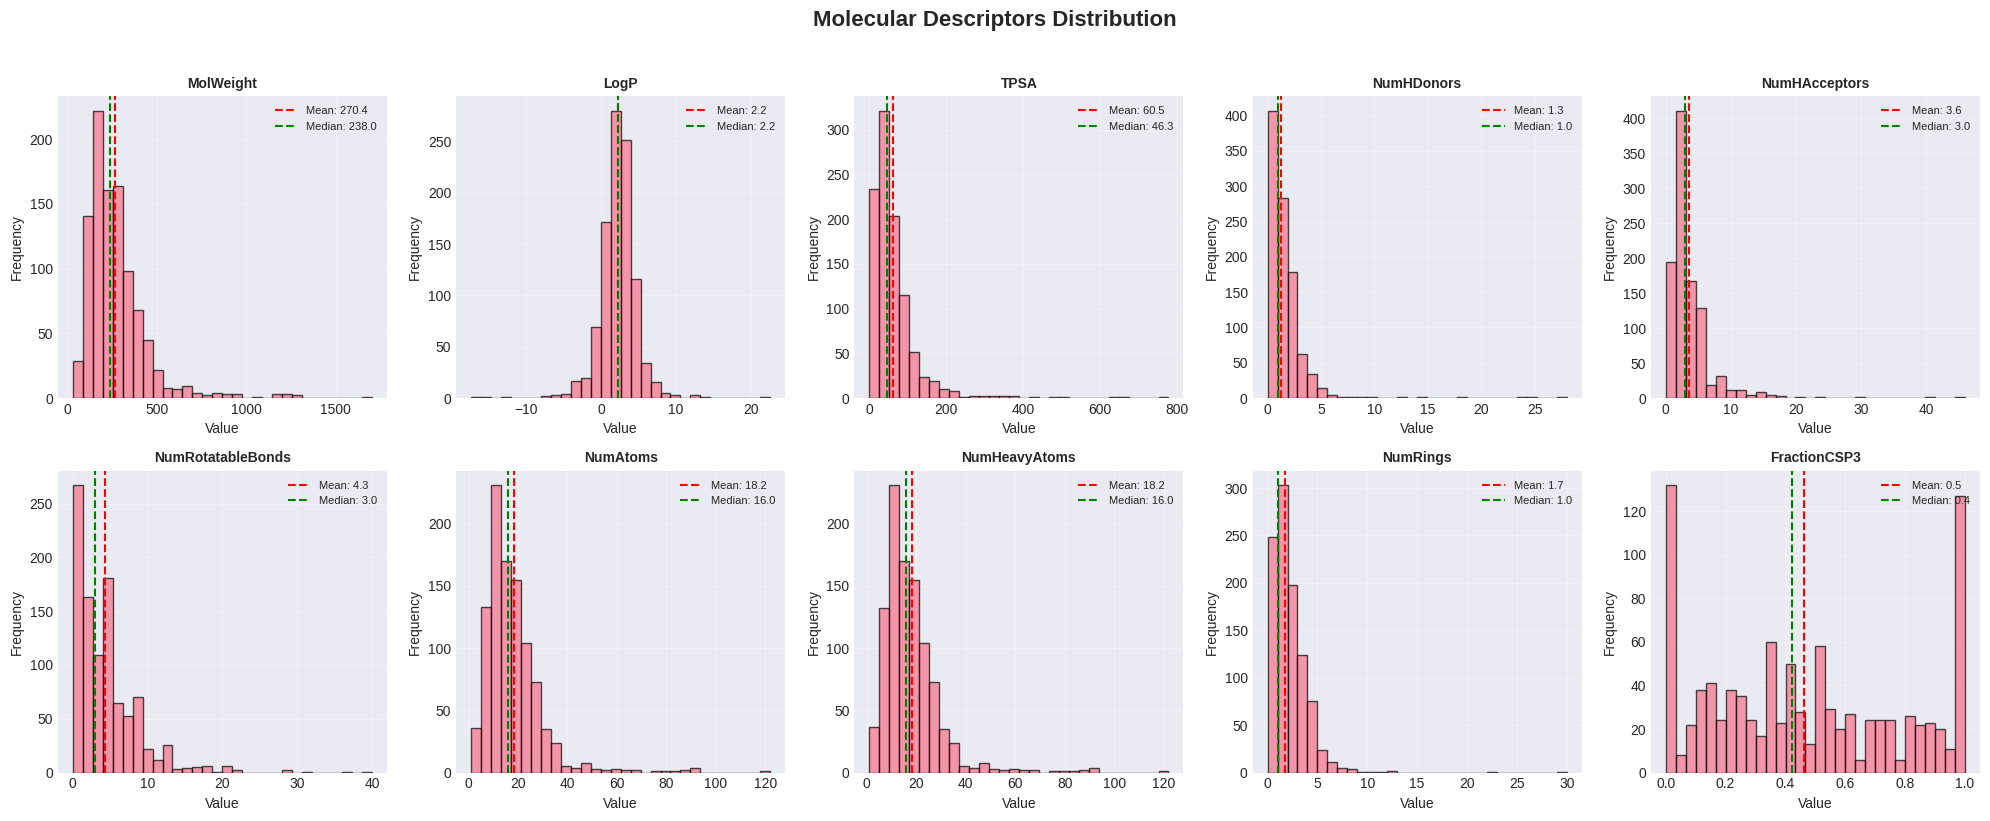

In [10]:
# 2.3 Descriptors visualization
print("\n📊 2.3 MOLECULAR DESCRIPTORS VISUALIZATION")

# Select numeric descriptors
numeric_descriptors = ['MolWeight', 'LogP', 'TPSA', 'NumHDonors', 
                       'NumHAcceptors', 'NumRotatableBonds', 'NumAtoms',
                       'NumHeavyAtoms', 'NumRings', 'FractionCSP3']

fig, axes = plt.subplots(2, 5, figsize=(20, 8))
axes = axes.flatten()

for idx, descriptor in enumerate(numeric_descriptors):
    if idx < len(axes):
        ax = axes[idx]
        data = df_descriptors[descriptor].dropna()
        
        # Histogram
        ax.hist(data, bins=30, edgecolor='black', alpha=0.7, 
               color=sns.color_palette("husl", 1)[0])
        
        # Add statistical lines
        ax.axvline(data.mean(), color='red', linestyle='--', 
                  label=f'Mean: {data.mean():.1f}')
        ax.axvline(data.median(), color='green', linestyle='--', 
                  label=f'Median: {data.median():.1f}')
        
        ax.set_title(descriptor, fontsize=10, fontweight='bold')
        ax.set_xlabel('Value')
        ax.set_ylabel('Frequency')
        ax.legend(fontsize=8)
        ax.grid(True, alpha=0.3)

plt.suptitle('Molecular Descriptors Distribution', fontsize=16, y=1.02, fontweight='bold')
plt.tight_layout()
plt.show()


🔗 2.4 CORRELATION BETWEEN MOLECULAR DESCRIPTORS


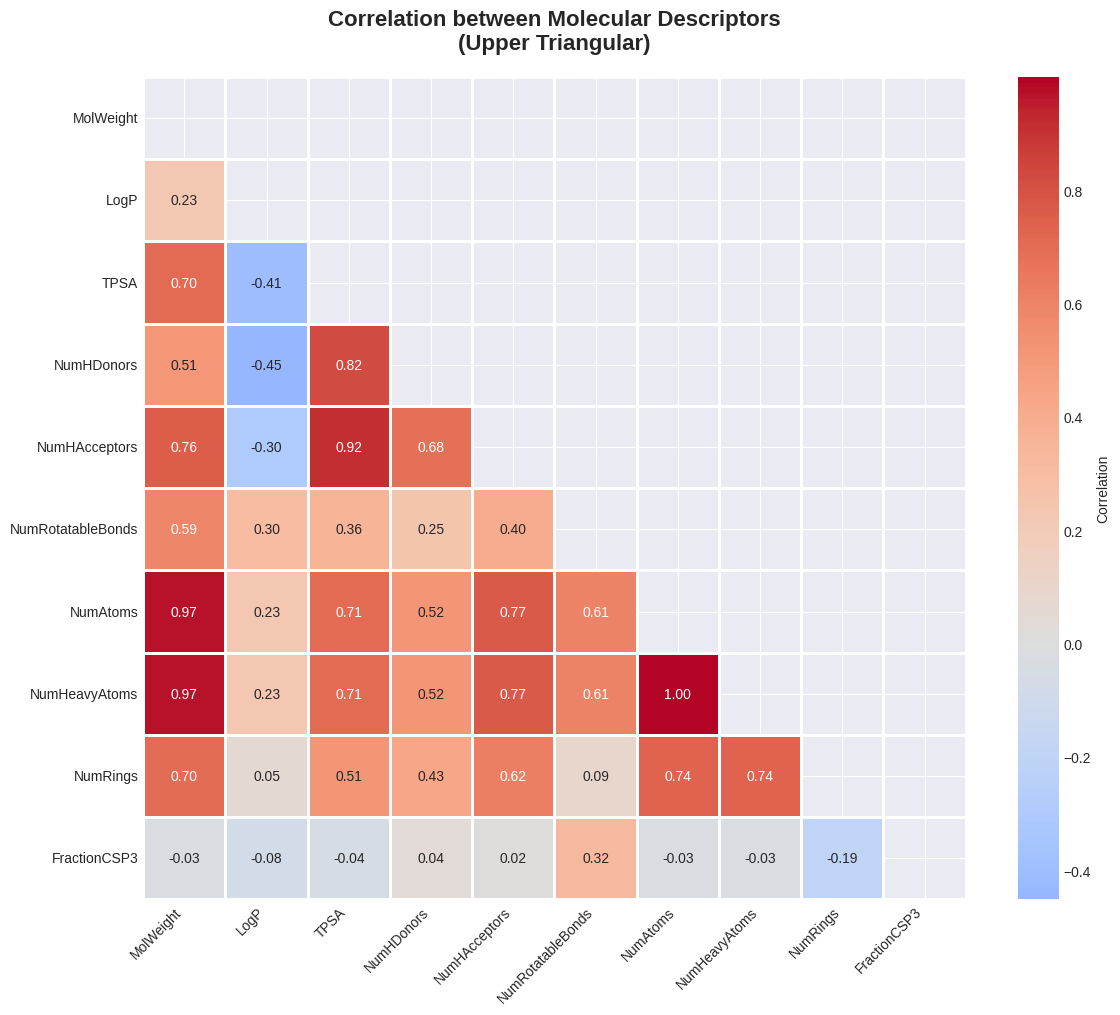


🔍 Strong correlations between descriptors (|r| > 0.7):


,Descriptor 1,Descriptor 2,Correlation
10,NumAtoms,NumHeavyAtoms,0.999996
3,MolWeight,NumHeavyAtoms,0.968209
2,MolWeight,NumAtoms,0.968206
5,TPSA,NumHAcceptors,0.917091
4,TPSA,NumHDonors,0.820165
9,NumHAcceptors,NumHeavyAtoms,0.771025
8,NumHAcceptors,NumAtoms,0.771010
1,MolWeight,NumHAcceptors,0.761128
12,NumHeavyAtoms,NumRings,0.738153
11,NumAtoms,NumRings,0.738145


In [11]:
# 2.4 Molecular descriptors correlation matrix
print("\n🔗 2.4 CORRELATION BETWEEN MOLECULAR DESCRIPTORS")

# Calculate correlation matrix
desc_corr = df_descriptors[numeric_descriptors].corr()

plt.figure(figsize=(12, 10))
mask = np.triu(np.ones_like(desc_corr, dtype=bool))
sns.heatmap(desc_corr, mask=mask, annot=True, cmap='coolwarm',
           center=0, fmt='.2f', linewidths=1, linecolor='white',
           square=True, cbar_kws={'label': 'Correlation'})

plt.title('Correlation between Molecular Descriptors\n(Upper Triangular)', 
          fontsize=16, pad=20, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# Identify strong correlations between descriptors
print("\n🔍 Strong correlations between descriptors (|r| > 0.7):")
strong_desc_corr = []
for i in range(len(desc_corr.columns)):
    for j in range(i+1, len(desc_corr.columns)):
        corr = desc_corr.iloc[i, j]
        if abs(corr) > 0.7 and not np.isnan(corr):
            strong_desc_corr.append({
                'Descriptor 1': desc_corr.columns[i],
                'Descriptor 2': desc_corr.columns[j],
                'Correlation': corr
            })

if strong_desc_corr:
    strong_desc_df = pd.DataFrame(strong_desc_corr)
    display(strong_desc_df.sort_values('Correlation', ascending=False))

3. DESCRIPTORS-TOXICITY RELATIONSHIP ANALYSIS

⚖️ 3.1 DESCRIPTORS COMPARISON BY TOXICITY CLASS


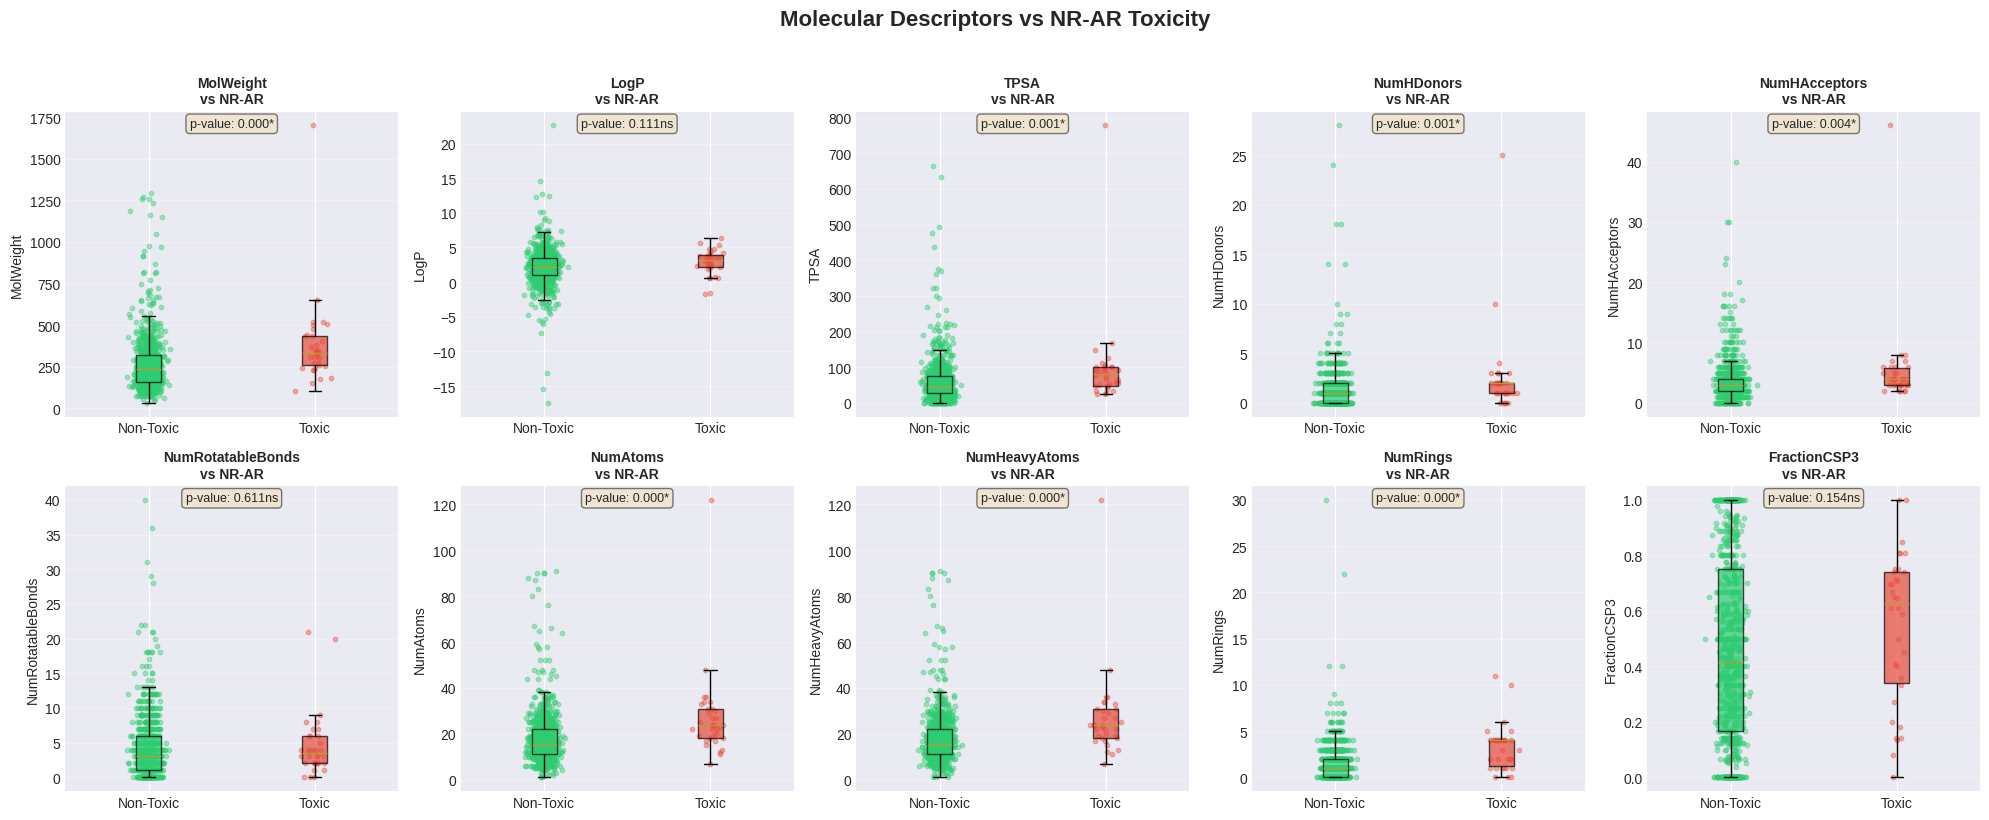

In [12]:
# 3. TOXICITY ANALYSIS BY DESCRIPTORS
print("="*80)
print("3. DESCRIPTORS-TOXICITY RELATIONSHIP ANALYSIS")
print("="*80)

# 3.1 Descriptors comparison by toxicity class
print("\n⚖️ 3.1 DESCRIPTORS COMPARISON BY TOXICITY CLASS")

# Select a target for analysis (NR-AR as example)
target_to_analyze = 'NR-AR'
df_target = df_descriptors.dropna(subset=[target_to_analyze, 'MolWeight']).copy()

if len(df_target) > 0:
    fig, axes = plt.subplots(2, 5, figsize=(20, 8))
    axes = axes.flatten()
    
    for idx, descriptor in enumerate(numeric_descriptors[:10]):
        if idx < len(axes):
            ax = axes[idx]
            
            # Separate by toxicity class
            toxic = df_target[df_target[target_to_analyze] == 1][descriptor].dropna()
            non_toxic = df_target[df_target[target_to_analyze] == 0][descriptor].dropna()
            
            # Create boxplot
            data_to_plot = [non_toxic, toxic]
            box = ax.boxplot(data_to_plot, patch_artist=True,
                           labels=['Non-Toxic', 'Toxic'],
                           showfliers=False)
            
            # Different colors for each group
            colors = ['#2ecc71', '#e74c3c']
            for patch, color in zip(box['boxes'], colors):
                patch.set_facecolor(color)
                patch.set_alpha(0.7)
            
            # Add data points (jitter)
            for i, group_data in enumerate(data_to_plot):
                if len(group_data) > 0:
                    x = np.random.normal(i + 1, 0.04, size=len(group_data))
                    ax.scatter(x, group_data, alpha=0.4, color=colors[i], s=10)
            
            ax.set_title(f'{descriptor}\nvs {target_to_analyze}', fontsize=10, fontweight='bold')
            ax.set_ylabel(descriptor)
            ax.grid(True, alpha=0.3, axis='y')
            
            # T-test for mean difference
            if len(toxic) > 1 and len(non_toxic) > 1:
                from scipy import stats
                t_stat, p_value = stats.ttest_ind(non_toxic, toxic, nan_policy='omit')
                if p_value < 0.05:
                    significance = '*'
                else:
                    significance = 'ns'
                ax.text(0.5, 0.95, f'p-value: {p_value:.3f}{significance}', 
                       transform=ax.transAxes, ha='center', fontsize=9,
                       bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    
    plt.suptitle(f'Molecular Descriptors vs {target_to_analyze} Toxicity', 
                fontsize=16, y=1.02, fontweight='bold')
    plt.tight_layout()
    plt.show()

In [13]:
# 4. MACHINE LEARNING MODELS
print("="*80)
print("4. MACHINE LEARNING MODELS FOR TOXICITY PREDICTION")
print("="*80)

# 4.1 Data preparation for ML
print("\n🔄 4.1 DATA PREPARATION FOR MACHINE LEARNING")

def prepare_ml_data(target_name='NR-AR', use_descriptors=True):
    """
    Prepare data for machine learning modeling
    
    Args:
        target_name: Name of target to model
        use_descriptors: Whether to use molecular descriptors
    
    Returns:
        X_train, X_test, y_train, y_test, feature_names
    """
    # Filter data with target and descriptors
    if use_descriptors:
        # Use the sample with descriptors
        df_ml = df_descriptors.dropna(subset=[target_name] + numeric_descriptors).copy()
        X = df_ml[numeric_descriptors].values
        feature_names = numeric_descriptors
    else:
        # Use simple features from original dataset
        df_ml = df.dropna(subset=[target_name]).copy()
        # Create simple features from SMILES
        df_ml['smiles_length'] = df_ml['smiles'].apply(lambda x: len(str(x)) if pd.notna(x) else 0)
        df_ml['has_aromatic'] = df_ml['smiles'].apply(lambda x: 1 if ('c' in str(x) or 'C' in str(x)) else 0)
        simple_features = ['smiles_length', 'has_aromatic']
        X = df_ml[simple_features].values
        feature_names = simple_features
    
    y = df_ml[target_name].values
    
    # Split data
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.3, random_state=42, stratify=y
    )
    
    return X_train, X_test, y_train, y_test, feature_names

# Test with NR-AR target
print("Preparing data for NR-AR target prediction...")
X_train, X_test, y_train, y_test, feature_names = prepare_ml_data('NR-AR', use_descriptors=True)

print(f"\nDataset shape:")
print(f"Training set: {X_train.shape}")
print(f"Test set: {X_test.shape}")
print(f"Features: {feature_names}")
print(f"Class distribution in training: {np.bincount(y_train.astype(int))}")
print(f"Class distribution in test: {np.bincount(y_test.astype(int))}")

4. MACHINE LEARNING MODELS FOR TOXICITY PREDICTION

🔄 4.1 DATA PREPARATION FOR MACHINE LEARNING
Preparing data for NR-AR target prediction...

Dataset shape:
Training set: (665, 10)
Test set: (286, 10)
Features: ['MolWeight', 'LogP', 'TPSA', 'NumHDonors', 'NumHAcceptors', 'NumRotatableBonds', 'NumAtoms', 'NumHeavyAtoms', 'NumRings', 'FractionCSP3']
Class distribution in training: [641  24]
Class distribution in test: [276  10]


In [14]:
# 4.2 Define ML pipelines
print("\n⚙️ 4.2 MACHINE LEARNING PIPELINES DEFINITION")

# Create ML pipelines
pipelines = {
    'Logistic Regression': Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler()),
        ('classifier', LogisticRegression(
            random_state=42, 
            class_weight='balanced',
            max_iter=1000,
            solver='liblinear'
        ))
    ]),
    
    'Random Forest': Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('classifier', RandomForestClassifier(
            random_state=42,
            class_weight='balanced',
            n_estimators=100,
            max_depth=10,
            min_samples_split=5,
            n_jobs=-1
        ))
    ]),
    
    'Gradient Boosting': Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('classifier', GradientBoostingClassifier(
            random_state=42,
            n_estimators=100,
            max_depth=5,
            learning_rate=0.1
        ))
    ]),
    
    'Random Forest with Feature Selection': Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('selector', SelectKBest(f_classif, k=5)),
        ('classifier', RandomForestClassifier(
            random_state=42,
            class_weight='balanced',
            n_estimators=100,
            n_jobs=-1
        ))
    ])
}


⚙️ 4.2 MACHINE LEARNING PIPELINES DEFINITION



🎯 4.3 MODEL TRAINING AND EVALUATION

Training: Logistic Regression
Accuracy: 0.7797
AUC-ROC: 0.8424
Precision (Toxic): 0.5534
Recall (Toxic): 0.7895
F1-Score (Toxic): 0.5374
CV AUC (5-fold): 0.6283 (+/- 0.1438)


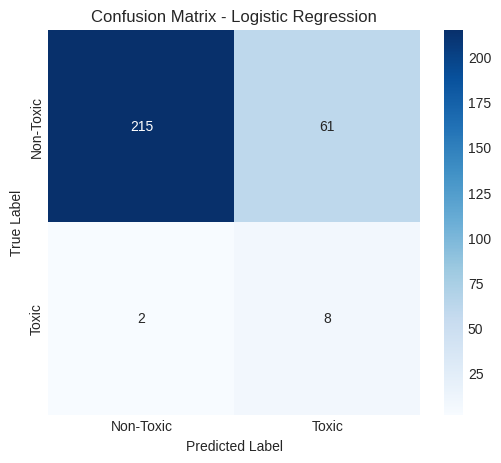


Training: Random Forest
Accuracy: 0.9685
AUC-ROC: 0.7851
Precision (Toxic): 0.7875
Recall (Toxic): 0.6464
F1-Score (Toxic): 0.6919
CV AUC (5-fold): 0.6315 (+/- 0.1689)


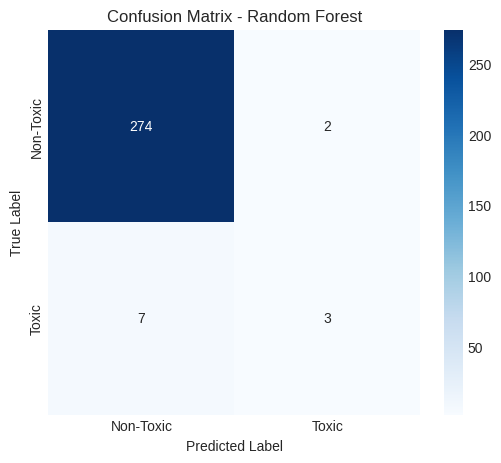


Training: Gradient Boosting
Accuracy: 0.9685
AUC-ROC: 0.7426
Precision (Toxic): 0.7688
Recall (Toxic): 0.7428
F1-Score (Toxic): 0.7550
CV AUC (5-fold): 0.7297 (+/- 0.1786)


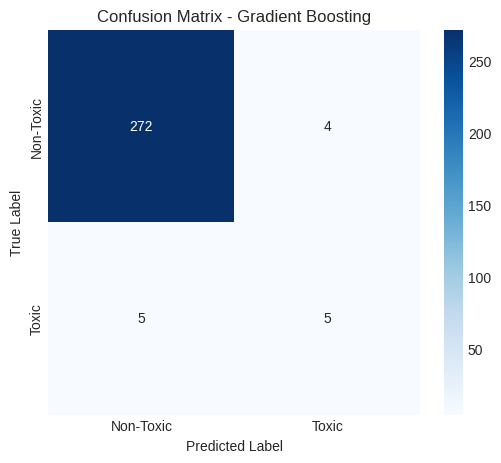


Training: Random Forest with Feature Selection
Accuracy: 0.9685
AUC-ROC: 0.6746
Precision (Toxic): 0.9842
Recall (Toxic): 0.5500
F1-Score (Toxic): 0.5829
CV AUC (5-fold): 0.6563 (+/- 0.1765)


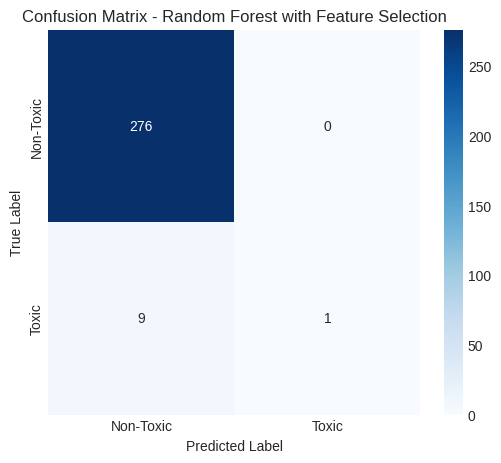

In [15]:
# 4.3 Model training and evaluation - FIXED VERSION
print("\n🎯 4.3 MODEL TRAINING AND EVALUATION")

results = {}
best_model = None
best_score = 0

for model_name, pipeline in pipelines.items():
    print(f"\n{'='*60}")
    print(f"Training: {model_name}")
    print(f"{'='*60}")
    
    # Train the model
    pipeline.fit(X_train, y_train)
    
    # Make predictions
    y_pred = pipeline.predict(X_test)
    y_pred_proba = pipeline.predict_proba(X_test)[:, 1]
    
    # Calculate metrics
    accuracy = accuracy_score(y_test, y_pred)
    auc_score = roc_auc_score(y_test, y_pred_proba)
    
    # Get classification report - with error handling
    report = classification_report(y_test, y_pred, output_dict=True)
    
    # Handle cases where '1' key might not exist
    precision = recall = f1 = 0.0
    if '1' in report:
        precision = report['1']['precision']
        recall = report['1']['recall']
        f1 = report['1']['f1-score']
    else:
        print(f"Warning: No toxic samples (class 1) in test set for {model_name}")
        # Use micro/macro average or other metrics
        if 'macro avg' in report:
            precision = report['macro avg']['precision']
            recall = report['macro avg']['recall']
            f1 = report['macro avg']['f1-score']
    
    # Cross-validation scores
    try:
        cv_scores = cross_val_score(pipeline, X_train, y_train, 
                                    cv=5, scoring='roc_auc', n_jobs=-1)
        cv_mean = cv_scores.mean()
        cv_std = cv_scores.std()
    except:
        print(f"Warning: CV failed for {model_name}")
        cv_mean = 0.0
        cv_std = 0.0
    
    # Store results
    results[model_name] = {
        'accuracy': accuracy,
        'auc': auc_score,
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'cv_mean': cv_mean,
        'cv_std': cv_std,
        'model': pipeline
    }
    
    print(f"Accuracy: {accuracy:.4f}")
    print(f"AUC-ROC: {auc_score:.4f}")
    print(f"Precision (Toxic): {precision:.4f}")
    print(f"Recall (Toxic): {recall:.4f}")
    print(f"F1-Score (Toxic): {f1:.4f}")
    print(f"CV AUC (5-fold): {cv_mean:.4f} (+/- {cv_std*2:.4f})")
    
    # Track best model
    if auc_score > best_score:
        best_score = auc_score
        best_model = model_name
    
    # Display confusion matrix for each model
    cm = confusion_matrix(y_test, y_pred)
    
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
               xticklabels=['Non-Toxic', 'Toxic'],
               yticklabels=['Non-Toxic', 'Toxic'])
    plt.title(f'Confusion Matrix - {model_name}')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.show()


📊 4.4 MODEL PERFORMANCE COMPARISON

Performance Comparison:


,Accuracy,AUC-ROC,Precision,Recall,F1-Score,CV AUC
Logistic Regression,0.7797,0.8424,0.5534,0.7895,0.5374,0.6283
Random Forest,0.9685,0.7851,0.7875,0.6464,0.6919,0.6315
Gradient Boosting,0.9685,0.7426,0.7688,0.7428,0.7550,0.7297
Random Forest with Feature Selection,0.9685,0.6746,0.9842,0.5500,0.5829,0.6563


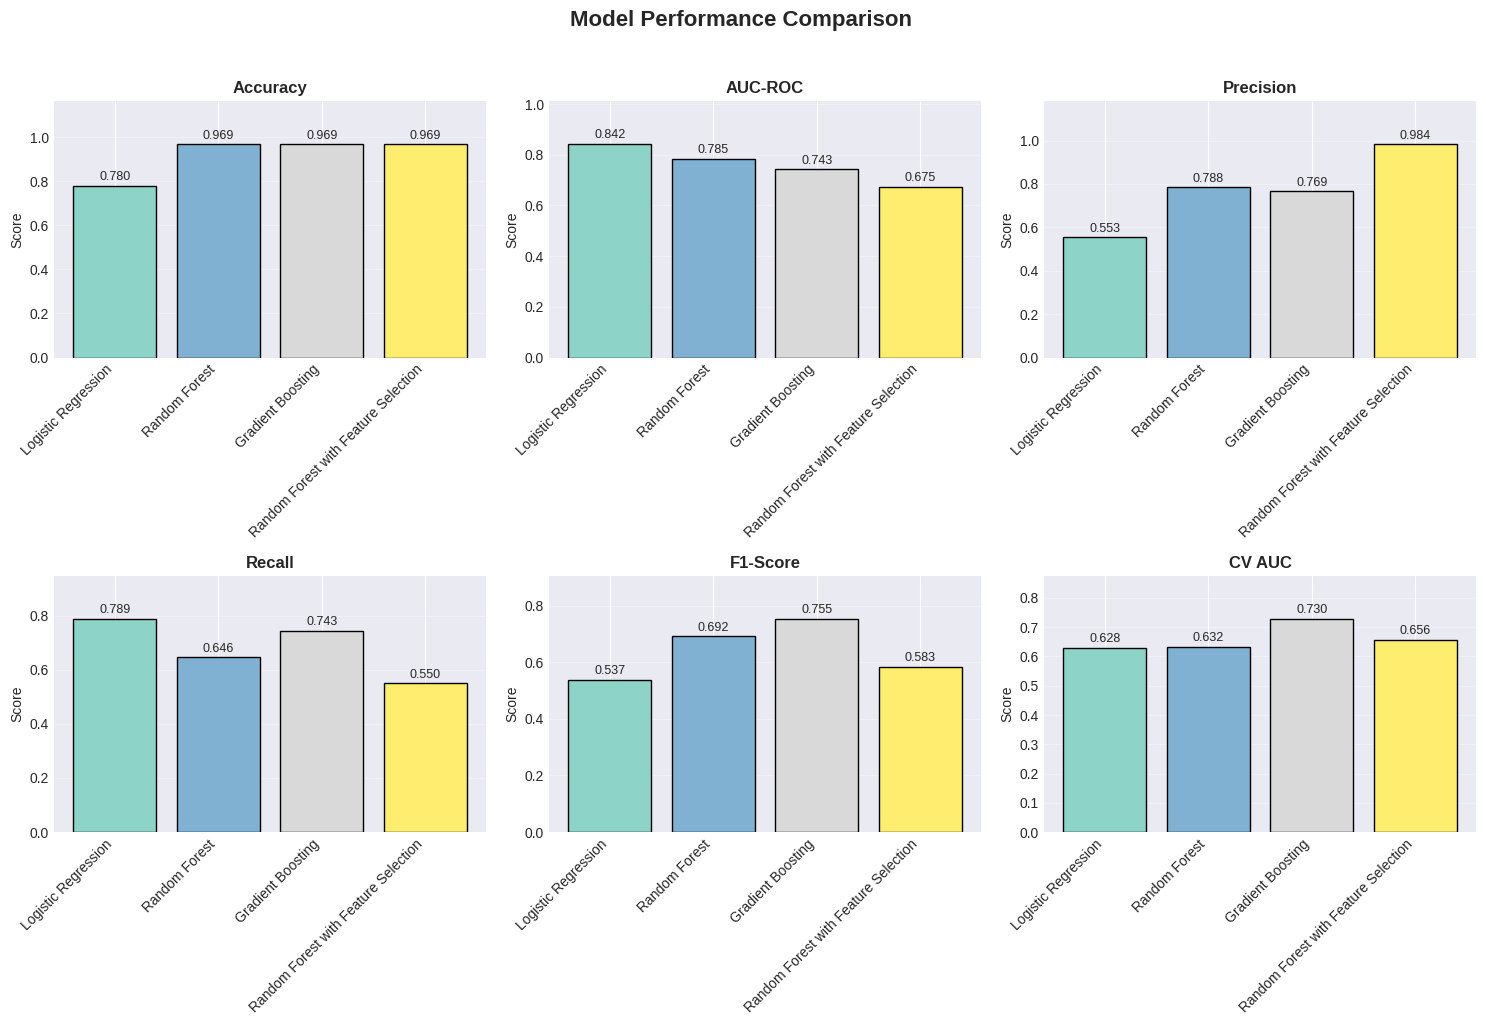

In [16]:
# 4.4 Results comparison
print("\n📊 4.4 MODEL PERFORMANCE COMPARISON")

# Convert results to DataFrame
results_df = pd.DataFrame(results).T
results_display = results_df[['accuracy', 'auc', 'precision', 'recall', 'f1', 'cv_mean']]
results_display.columns = ['Accuracy', 'AUC-ROC', 'Precision', 'Recall', 'F1-Score', 'CV AUC']

print("\nPerformance Comparison:")
display(results_display.style.format('{:.4f}').background_gradient(cmap='YlOrRd'))

# Visualization of results
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

metrics = ['Accuracy', 'AUC-ROC', 'Precision', 'Recall', 'F1-Score', 'CV AUC']
colors = plt.cm.Set3(np.linspace(0, 1, len(results_df)))

for idx, metric in enumerate(metrics):
    ax = axes[idx]
    values = results_display[metric]
    
    bars = ax.bar(range(len(values)), values, color=colors, edgecolor='black')
    
    # Add value labels
    for bar, value in zip(bars, values):
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height + 0.01,
               f'{value:.3f}', ha='center', va='bottom', fontsize=9)
    
    ax.set_title(metric, fontsize=12, fontweight='bold')
    ax.set_xticks(range(len(values)))
    ax.set_xticklabels(results_display.index, rotation=45, ha='right')
    ax.set_ylabel('Score')
    ax.grid(True, alpha=0.3, axis='y')
    
    # Set y-axis limit
    ax.set_ylim([0, max(values) * 1.2])

plt.suptitle('Model Performance Comparison', fontsize=16, y=1.02, fontweight='bold')
plt.tight_layout()
plt.show()


📈 4.5 ROC CURVES COMPARISON


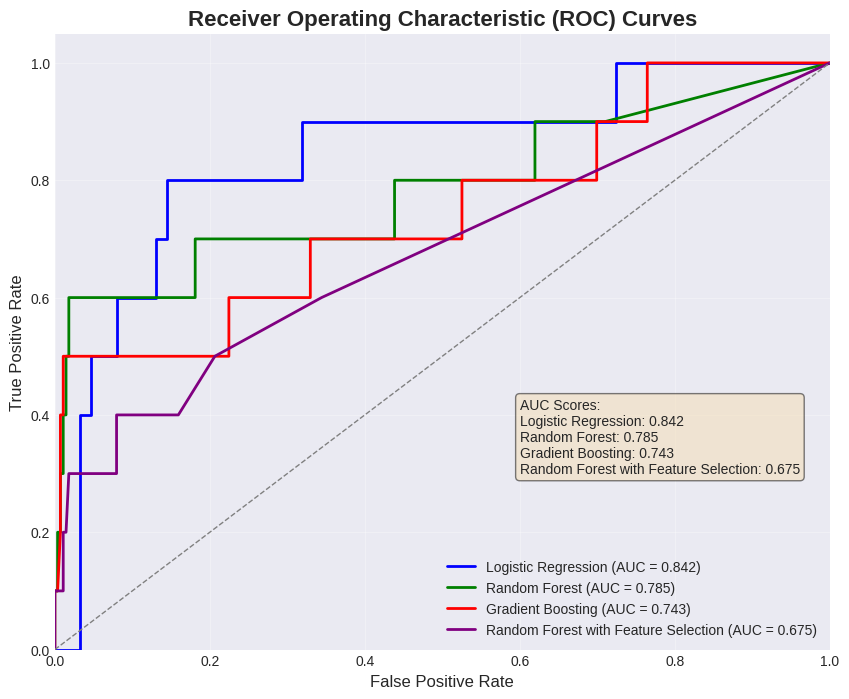

In [17]:
# 4.5 ROC curves comparison
print("\n📈 4.5 ROC CURVES COMPARISON")

plt.figure(figsize=(10, 8))
colors = ['blue', 'green', 'red', 'purple', 'orange']

for idx, (model_name, result) in enumerate(results.items()):
    if 'model' in result:
        # Get predictions
        y_pred_proba = result['model'].predict_proba(X_test)[:, 1]
        
        # Calculate ROC curve
        fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
        roc_auc = auc(fpr, tpr)
        
        # Plot ROC curve
        plt.plot(fpr, tpr, color=colors[idx % len(colors)], 
                lw=2, label=f'{model_name} (AUC = {roc_auc:.3f})')

# Plot diagonal line
plt.plot([0, 1], [0, 1], color='gray', lw=1, linestyle='--')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('Receiver Operating Characteristic (ROC) Curves', 
          fontsize=16, fontweight='bold')
plt.legend(loc='lower right', fontsize=10)
plt.grid(True, alpha=0.3)

# Add AUC text box
auc_text = '\n'.join([f'{model}: {results[model]["auc"]:.3f}' 
                      for model in results.keys()])
plt.text(0.6, 0.3, 'AUC Scores:\n' + auc_text, 
         fontsize=10, bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.show()


🔍 4.6 FEATURE IMPORTANCE ANALYSIS

Top 10 Most Important Features:


,Feature,Importance
2,TPSA,0.149995
0,MolWeight,0.117633
1,LogP,0.112900
9,FractionCSP3,0.102425
7,NumHeavyAtoms,0.102000
3,NumHDonors,0.099703
6,NumAtoms,0.093623
8,NumRings,0.087994
4,NumHAcceptors,0.074178
5,NumRotatableBonds,0.059549


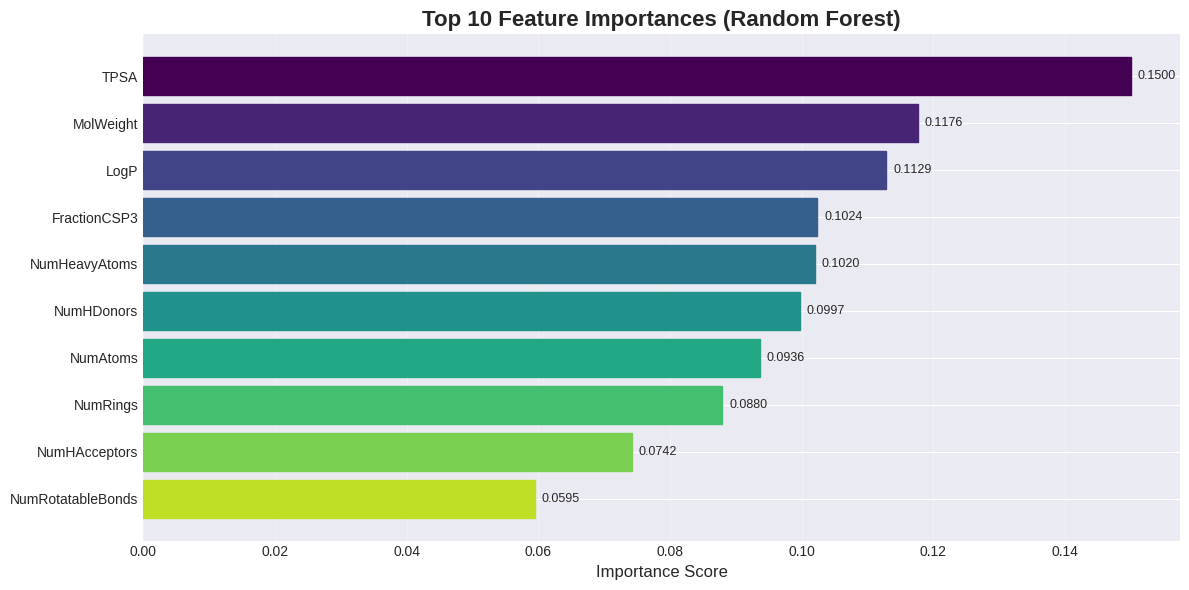

In [18]:
# 4.6 Feature importance analysis
print("\n🔍 4.6 FEATURE IMPORTANCE ANALYSIS")

# Get the best model (Random Forest)
if 'Random Forest' in results:
    rf_model = results['Random Forest']['model']
    
    # Get feature importances
    if hasattr(rf_model.named_steps['classifier'], 'feature_importances_'):
        importances = rf_model.named_steps['classifier'].feature_importances_
        
        # Create feature importance dataframe
        feat_importance = pd.DataFrame({
            'Feature': feature_names,
            'Importance': importances
        }).sort_values('Importance', ascending=False)
        
        print("\nTop 10 Most Important Features:")
        display(feat_importance.head(10))
        
        # Visualize feature importances
        plt.figure(figsize=(12, 6))
        bars = plt.barh(feat_importance['Feature'][:10], 
                       feat_importance['Importance'][:10])
        
        # Color bars by importance
        for i, bar in enumerate(bars):
            bar.set_color(plt.cm.viridis(i/len(bars)))
        
        plt.xlabel('Importance Score', fontsize=12)
        plt.title('Top 10 Feature Importances (Random Forest)', 
                  fontsize=16, fontweight='bold')
        plt.gca().invert_yaxis()
        plt.grid(True, alpha=0.3, axis='x')
        
        # Add values on bars
        for bar in bars:
            width = bar.get_width()
            plt.text(width + 0.001, bar.get_y() + bar.get_height()/2,
                    f'{width:.4f}', va='center', fontsize=9)
        
        plt.tight_layout()
        plt.show()

5. MULTI-TARGET TOXICITY ANALYSIS

🎯 5.1 MODEL PERFORMANCE ACROSS DIFFERENT TARGETS

Analyzing target: NR-AR

Analyzing target: NR-AhR

Analyzing target: NR-ER

Analyzing target: SR-ARE

Multi-target Analysis Results:


,Target,Training Samples,Test Samples,Positive Rate (%),AUC-ROC
0,NR-AR,665,286,3.609023,0.781703
1,NR-AhR,600,258,14.333333,0.824752
2,NR-ER,567,244,13.403880,0.764398
3,SR-ARE,515,221,16.504854,0.679129


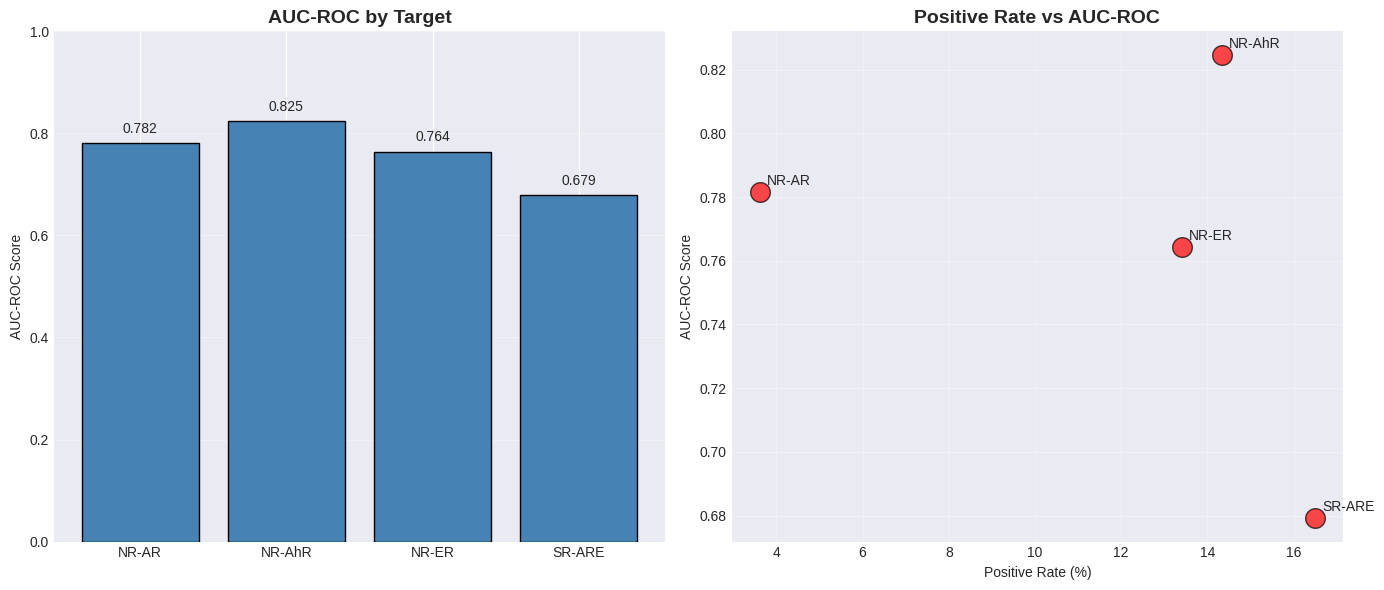

In [19]:
# 5. ADVANCED ANALYSIS: MULTIPLE TARGETS
print("="*80)
print("5. MULTI-TARGET TOXICITY ANALYSIS")
print("="*80)

# 5.1 Model performance across different targets
print("\n🎯 5.1 MODEL PERFORMANCE ACROSS DIFFERENT TARGETS")

# Select a subset of targets for analysis
selected_targets = ['NR-AR', 'NR-AhR', 'NR-ER', 'SR-ARE']
multi_target_results = []

for target in selected_targets:
    print(f"\nAnalyzing target: {target}")
    
    # Prepare data
    X_train, X_test, y_train, y_test, _ = prepare_ml_data(target, use_descriptors=True)
    
    # Train Random Forest (as baseline)
    rf_pipeline = Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler()),
        ('classifier', RandomForestClassifier(
            random_state=42,
            class_weight='balanced',
            n_estimators=100,
            n_jobs=-1
        ))
    ])
    
    rf_pipeline.fit(X_train, y_train)
    y_pred_proba = rf_pipeline.predict_proba(X_test)[:, 1]
    auc_score = roc_auc_score(y_test, y_pred_proba)
    
    # Store results
    multi_target_results.append({
        'Target': target,
        'Training Samples': len(y_train),
        'Test Samples': len(y_test),
        'Positive Rate (%)': (y_train.mean() * 100),
        'AUC-ROC': auc_score
    })

# Display results
multi_target_df = pd.DataFrame(multi_target_results)
print("\nMulti-target Analysis Results:")
display(multi_target_df)

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# AUC comparison
axes[0].bar(multi_target_df['Target'], multi_target_df['AUC-ROC'], 
           color='steelblue', edgecolor='black')
axes[0].set_title('AUC-ROC by Target', fontsize=14, fontweight='bold')
axes[0].set_ylabel('AUC-ROC Score')
axes[0].set_ylim([0, 1])
axes[0].grid(True, alpha=0.3, axis='y')

# Add value labels
for idx, row in multi_target_df.iterrows():
    axes[0].text(idx, row['AUC-ROC'] + 0.02, f'{row["AUC-ROC"]:.3f}', 
                ha='center', fontsize=10)

# Positive rate vs AUC
scatter = axes[1].scatter(multi_target_df['Positive Rate (%)'], 
                         multi_target_df['AUC-ROC'], 
                         s=200, c='red', edgecolor='black', alpha=0.7)

axes[1].set_title('Positive Rate vs AUC-ROC', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Positive Rate (%)')
axes[1].set_ylabel('AUC-ROC Score')
axes[1].grid(True, alpha=0.3)

# Add labels for each point
for idx, row in multi_target_df.iterrows():
    axes[1].annotate(row['Target'], 
                    (row['Positive Rate (%)'], row['AUC-ROC']),
                    xytext=(5, 5), textcoords='offset points',
                    fontsize=10)

plt.tight_layout()
plt.show()